# Timeseries classification from scratch (FordA / UCR)

**Standalone Kaggle notebook** — downloads [FordA](https://www.cs.ucr.edu/~eamonn/time_series_data_2018/) TSVs if missing.

Binary classification of engine-noise sensor traces (500 timesteps). Conv1D + batch norm + global average pooling.

**Credits:** [hfawaz](https://github.com/hfawaz/) — original Keras example.

**Dataset description**: <br>
The dataset we are using here is called FordA. The data comes from the UCR archive. The dataset contains 3601 training instances and another 1320 testing instances. Each timeseries corresponds to a measurement of engine noise captured by a motor sensor. For this task, the goal is to automatically detect the presence of a specific issue with the engine. The problem is a balanced binary classification task. The full description of this dataset can be found here.



In [1]:
# Optional: shorter run for smoke tests (set to True on Kaggle if needed)
QUICK_RUN = False  # True -> fewer epochs, smaller early-stopping patience

import os
import urllib.request
from pathlib import Path

import keras
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Inline plots on Kaggle
%matplotlib inline


In [2]:
def readucr(filename):
    data = np.loadtxt(filename, delimiter="\t")
    y = data[:, 0]
    x = data[:, 1:]
    return x, y.astype(int)


DATA_DIR = Path("data")
DATA_DIR.mkdir(parents=True, exist_ok=True)
FORDA_BASE = "https://raw.githubusercontent.com/hfawaz/cd-diagram/master/FordA/"


def ensure_forda_tsv(name: str) -> Path:
    path = DATA_DIR / name
    if not path.is_file():
        print("Downloading", name, "...")
        urllib.request.urlretrieve(FORDA_BASE + name, path)
    return path


x_train, y_train = readucr(ensure_forda_tsv("FordA_TRAIN.tsv"))
x_test, y_test = readucr(ensure_forda_tsv("FordA_TEST.tsv"))
print("Train:", x_train.shape, "Test:", x_test.shape)
print("Labels (train):", np.unique(y_train))


Train: (3601, 500) Test: (1320, 500)
Labels (train): [-1  1]


## Sample traces by class

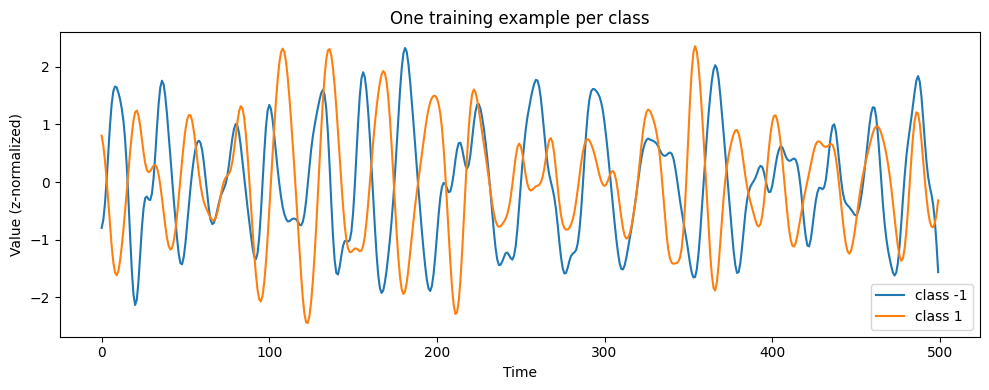

In [3]:
classes = np.unique(np.concatenate((y_train, y_test), axis=0))
plt.figure(figsize=(10, 4))
for c in classes:
    c_x_train = x_train[y_train == c]
    plt.plot(c_x_train[0], label=f"class {c}")
plt.legend(loc="best")
plt.title("One training example per class")
plt.xlabel("Time")
plt.ylabel("Value (z-normalized)")
plt.tight_layout()
plt.show()


## Preprocess: shape for Conv1D, shuffle, map labels {-1,1} -> {0,1}

In [4]:
x_train = x_train.reshape((x_train.shape[0], x_train.shape[1], 1))
x_test = x_test.reshape((x_test.shape[0], x_test.shape[1], 1))
num_classes = len(np.unique(y_train))

idx = np.random.permutation(len(x_train))
x_train, y_train = x_train[idx], y_train[idx]

y_train = y_train.copy()
y_test = y_test.copy()
y_train[y_train == -1] = 0
y_test[y_test == -1] = 0


## Model: fully convolutional network

In [5]:
def make_model(input_shape):
    inp = keras.layers.Input(input_shape)
    x = keras.layers.Conv1D(64, 3, padding="same")(inp)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.ReLU()(x)
    x = keras.layers.Conv1D(64, 3, padding="same")(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.ReLU()(x)
    x = keras.layers.Conv1D(64, 3, padding="same")(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.ReLU()(x)
    x = keras.layers.GlobalAveragePooling1D()(x)
    out = keras.layers.Dense(num_classes, activation="softmax")(x)
    return keras.models.Model(inp, out)


model = make_model(input_shape=x_train.shape[1:])
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 500, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 500, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 500, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 500, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 500, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 500, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 500, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 500, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 500, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 500, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,858 (101.01 KB)

 Trainable params: 25,474 (99.51 KB)

 Non-trainable params: 384 (1.50 KB)

In [6]:
try:
    keras.utils.plot_model(model, show_shapes=True, to_file="timeseries_class_model.png", dpi=120)
    print("Saved model diagram to timeseries_class_model.png")
except Exception as e:
    print("Skipping plot_model:", e)


You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.
Saved model diagram to timeseries_class_model.png


## Train

In [7]:
epochs = 15 if QUICK_RUN else 500
batch_size = 32
_es_patience = 5 if QUICK_RUN else 50
_rlr_patience = 3 if QUICK_RUN else 20

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "best_model.keras", save_best_only=True, monitor="val_loss"
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=_rlr_patience, min_lr=0.0001
    ),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=_es_patience, verbose=1),
]
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["sparse_categorical_accuracy"],
)
history = model.fit(
    x_train,
    y_train,
    batch_size=batch_size,
    epochs=epochs,
    callbacks=callbacks,
    validation_split=0.2,
    verbose=1,
)


Epoch 1/500
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.5623 - sparse_categorical_accuracy: 0.6760 - val_loss: 0.7417 - val_sparse_categorical_accuracy: 0.4951 - learning_rate: 0.0010
Epoch 2/500
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.4704 - sparse_categorical_accuracy: 0.7622 - val_loss: 0.7690 - val_sparse_categorical_accuracy: 0.4951 - learning_rate: 0.0010
Epoch 3/500
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.4492 - sparse_categorical_accuracy: 0.7823 - val_loss: 0.7185 - val_sparse_categorical_accuracy: 0.4951 - learning_rate: 0.0010
Epoch 4/500
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.4297 - sparse_categorical_accuracy: 0.7819 - val_loss: 0.6733 - val_sparse_categorical_accuracy: 0.5645 - learning_rate: 0.0010
Epoch 5/500
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.4192 - sparse_categorical_accuracy: 0.7955 - val_loss: 0.5625 - val_sparse_categorical_accuracy: 0.7212 - learning_rate: 0.0010
Epoch 6/500
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/ste

## Test metrics, confusion matrix, and report

Test loss: 0.0922  |  Test accuracy: 0.9682


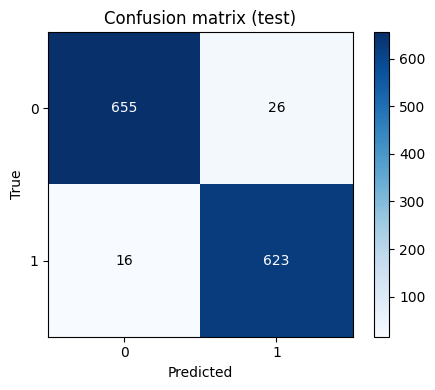

              precision    recall  f1-score   support

     class 0       0.98      0.96      0.97       681
     class 1       0.96      0.97      0.97       639

    accuracy                           0.97      1320
   macro avg       0.97      0.97      0.97      1320
weighted avg       0.97      0.97      0.97      1320



In [8]:
model = keras.models.load_model("best_model.keras")
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test loss: {test_loss:.4f}  |  Test accuracy: {test_acc:.4f}")

probs = model.predict(x_test, verbose=0)
y_pred = np.argmax(probs, axis=1)

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion matrix (test)")
for (i, j), v in np.ndenumerate(cm):
    ax.text(j, i, str(v), ha="center", va="center", color="black" if cm[i, j] < cm.max() / 2 else "white")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred, target_names=[f"class {c}" for c in sorted(np.unique(y_test))]))


## Training curves (accuracy & loss)

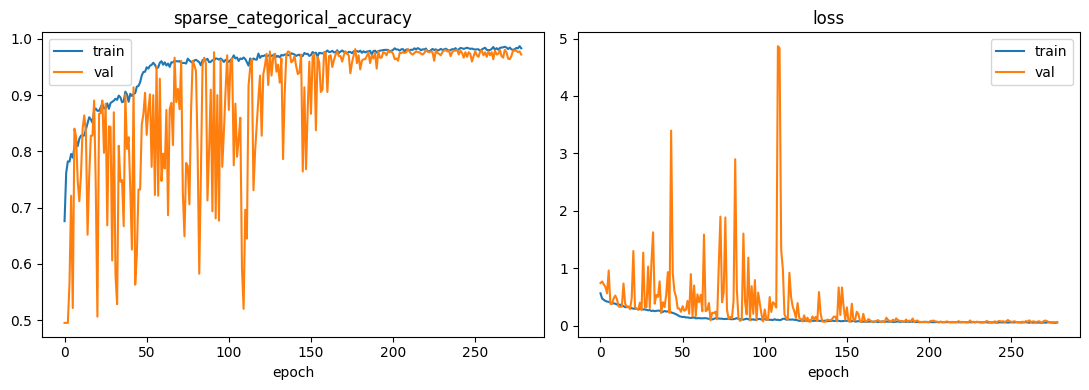

In [9]:
metric = "sparse_categorical_accuracy"
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history.history[metric], label="train")
axes[0].plot(history.history["val_" + metric], label="val")
axes[0].set_title(metric)
axes[0].set_xlabel("epoch")
axes[0].legend()

axes[1].plot(history.history["loss"], label="train")
axes[1].plot(history.history["val_loss"], label="val")
axes[1].set_title("loss")
axes[1].set_xlabel("epoch")
axes[1].legend()
plt.tight_layout()
plt.show()


## Prediction confidence on random test examples

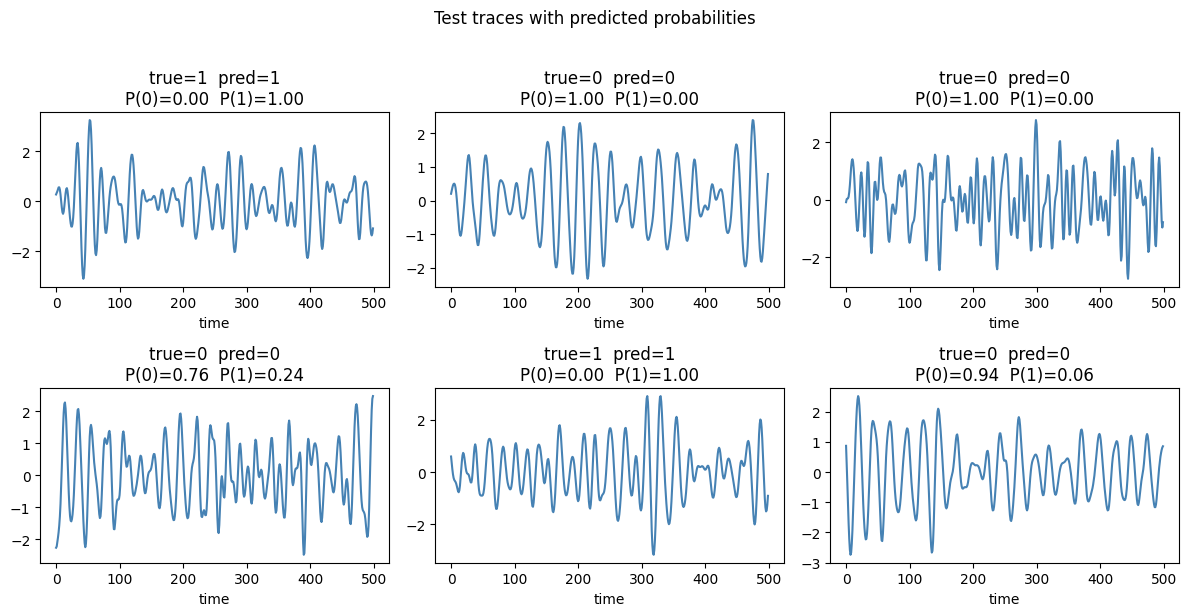

In [10]:
rng = np.random.default_rng(42)
idxs = rng.choice(len(x_test), size=6, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.ravel()
for ax, i in zip(axes, idxs):
    ax.plot(x_test[i].squeeze(), color="steelblue")
    true_c = int(y_test[i])
    pred_c = int(y_pred[i])
    p0, p1 = probs[i]
    ax.set_title(f"true={true_c}  pred={pred_c}\nP(0)={p0:.2f}  P(1)={p1:.2f}")
    ax.set_xlabel("time")
plt.suptitle("Test traces with predicted probabilities", y=1.02)
plt.tight_layout()
plt.show()
